In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [3]:
# ==========================================
# 1. LOAD AND PREPARE THE DATA
# ==========================================
df = pd.read_csv('./individual_stocks_5yr/AAP_data.csv')

# Ensure chronological order
df['date'] = pd.to_datetime(df['date'])
df.sort_values('date', inplace=True)

In [4]:
# ==========================================
# 2. FEATURE ENGINEERING
# ==========================================
# Just like Random Forest, K-Means will fail if you give it raw prices.
# We must give it contextual features that describe the "behavior" of the day.

# Feature 1: The Daily Return (Was it a green or red day?)
df['Daily_Return'] = df['close'].pct_change()

# Feature 2: Volatility (How chaotic was the market over the last 10 days?)
df['Volatility_10d'] = df['Daily_Return'].rolling(window=10).std()

# Drop rows with NaNs caused by the rolling window calculations
df.dropna(inplace=True)

# Select only our newly engineered features for clustering
features_to_cluster = ['Daily_Return', 'Volatility_10d']
X = df[features_to_cluster]

In [5]:
# ==========================================
# 3. STANDARDIZE THE DATA (Crucial Step for K-Means)
# ==========================================
# K-Means calculates distance between points. If "Daily_Return" is a tiny decimal
# like 0.01, and another feature like Volume was 1,000,000, K-Means would completely
# ignore the return and only cluster based on volume. Standardizing forces all features
# to have a mean of 0 and a standard deviation of 1, so they are weighed equally.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [6]:
# ==========================================
# 4. APPLY K-MEANS CLUSTERING
# ==========================================
# We tell the algorithm to find exactly 3 hidden groups (Market Regimes)
# n_init=10 means it will run 10 times with different random starting points to find the best fit
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

# The algorithm assigns every single trading day a label: 0, 1, or 2.
df['Cluster'] = kmeans.fit_predict(X_scaled)

Analysis of Discovered Market Regimes:
         Daily_Return  Volatility_10d  Day Count
Cluster                                         
0            0.007513        0.012779        747
1           -0.014995        0.014764        413
2            0.012747        0.047126         89


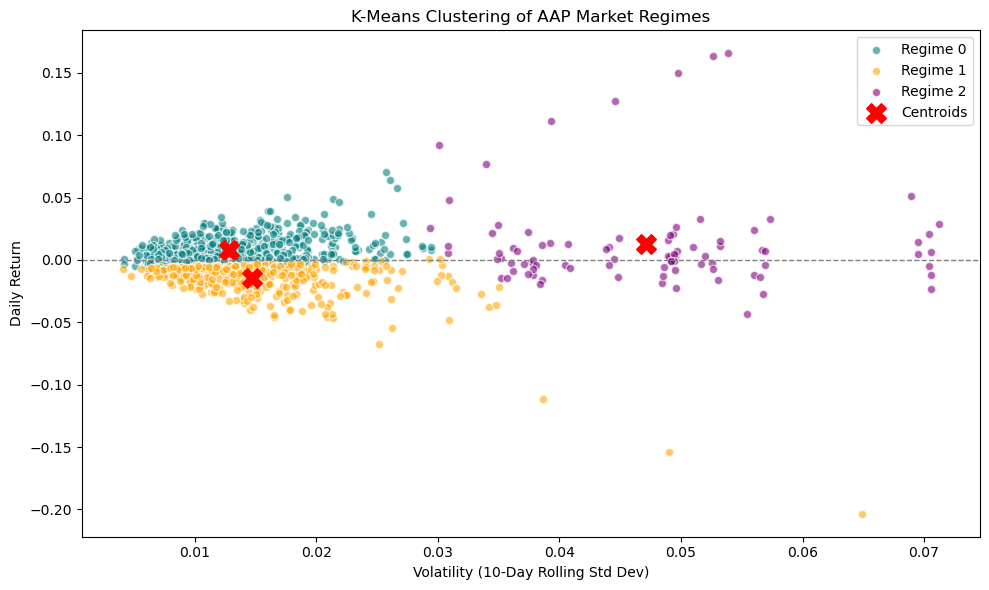

In [7]:
# ==========================================
# 5. ANALYZE AND VISUALIZE THE REGIMES
# ==========================================
# Let's print out the average stats for the clusters the AI found
cluster_analysis = df.groupby('Cluster')[['Daily_Return', 'Volatility_10d']].mean()
cluster_counts = df['Cluster'].value_counts().sort_index()
cluster_analysis['Day Count'] = cluster_counts

print("Analysis of Discovered Market Regimes:")
print(cluster_analysis)

# Plotting the results
plt.figure(figsize=(10, 6))
colors = ['teal', 'orange', 'purple']

for i in range(3):
    cluster_data = df[df['Cluster'] == i]
    plt.scatter(
        cluster_data['Volatility_10d'],
        cluster_data['Daily_Return'],
        c=colors[i],
        label=f'Regime {i}',
        alpha=0.6,
        edgecolors='w'
    )

# Overlay the "Centroids" (The mathematical dead-center of each group)
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centroids[:, 1], centroids[:, 0], c='red', s=200, marker='X', label='Centroids')

plt.title('K-Means Clustering of AAP Market Regimes')
plt.xlabel('Volatility (10-Day Rolling Std Dev)')
plt.ylabel('Daily Return')
plt.axhline(0, color='gray', linestyle='--', linewidth=1) # Adds a 0% return line for reference
plt.legend()
plt.tight_layout()
plt.show()